In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('9.shipping.csv')

In [3]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [5]:
df.nunique()

ID                     10999
Warehouse_block            5
Mode_of_Shipment           3
Customer_care_calls        6
Customer_rating            5
Cost_of_the_Product      215
Prior_purchases            8
Product_importance         3
Gender                     2
Discount_offered          65
Weight_in_gms           4034
Reached.on.Time_Y.N        2
dtype: int64

In [6]:
co=df.select_dtypes('number').corr()

In [7]:
co

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,1.000000,0.188998,-0.005722,0.196791,0.145369,-0.598278,0.278312,-0.411822
Customer_care_calls,0.188998,1.000000,0.012209,0.323182,0.180771,-0.130750,-0.276615,-0.067126
Customer_rating,-0.005722,0.012209,1.000000,0.009270,0.013179,-0.003124,-0.001897,0.013119
Cost_of_the_Product,0.196791,0.323182,0.009270,1.000000,0.123676,-0.138312,-0.132604,-0.073587
Prior_purchases,0.145369,0.180771,0.013179,0.123676,1.000000,-0.082769,-0.168213,-0.055515
Discount_offered,-0.598278,-0.130750,-0.003124,-0.138312,-0.082769,1.000000,-0.376067,0.397108
Weight_in_gms,0.278312,-0.276615,-0.001897,-0.132604,-0.168213,-0.376067,1.000000,-0.268793
Reached.on.Time_Y.N,-0.411822,-0.067126,0.013119,-0.073587,-0.055515,0.397108,-0.268793,1.000000


<Axes: >

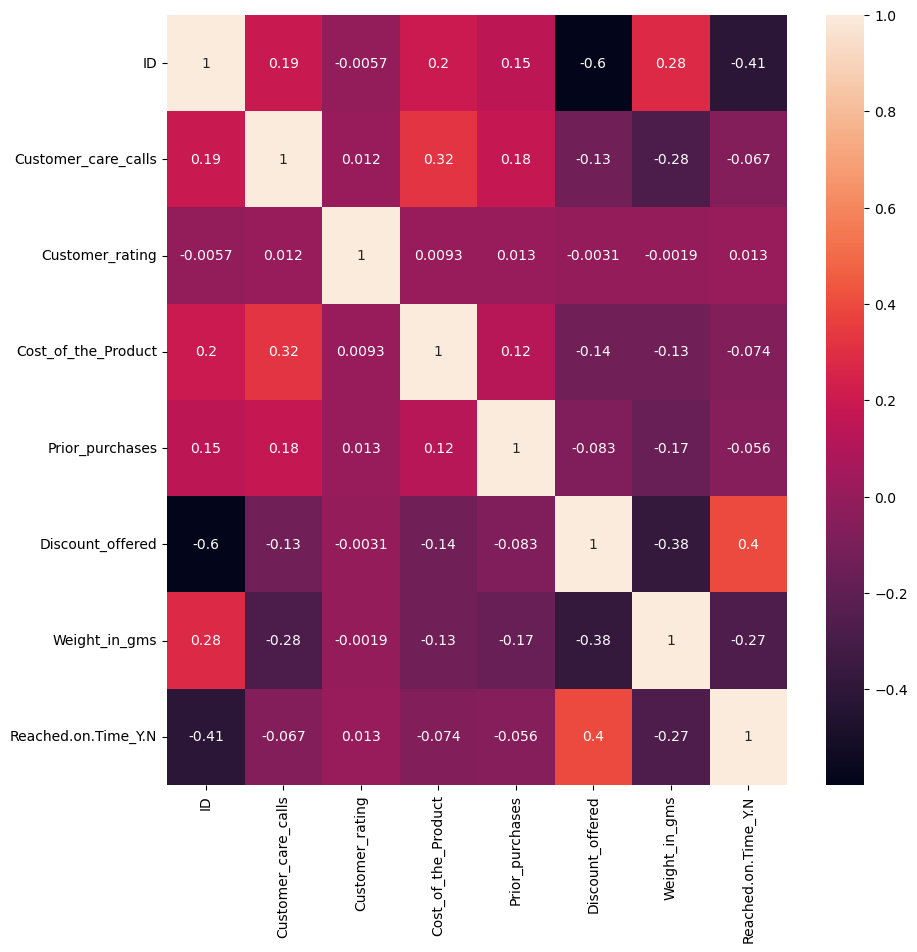

In [8]:
plt.figure(figsize=(10,10))
sns.heatmap(co,annot=True)

In [9]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

<Axes: xlabel='Mode_of_Shipment', ylabel='count'>

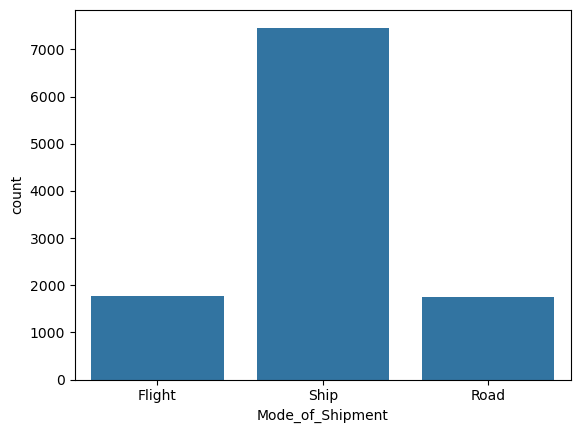

In [10]:
sns.countplot(x=df['Mode_of_Shipment'])

<Axes: title={'center': 'Reached On Time'}, ylabel='count'>

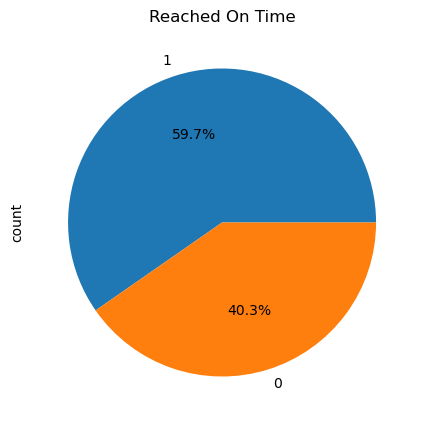

In [11]:
df['Reached.on.Time_Y.N'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), title='Reached On Time')


In [12]:
df.dtypes

ID                      int64
Warehouse_block        object
Mode_of_Shipment       object
Customer_care_calls     int64
Customer_rating         int64
Cost_of_the_Product     int64
Prior_purchases         int64
Product_importance     object
Gender                 object
Discount_offered        int64
Weight_in_gms           int64
Reached.on.Time_Y.N     int64
dtype: object

In [13]:
df=pd.get_dummies(df,columns=['Warehouse_block','Mode_of_Shipment','Product_importance','Gender'],drop_first=True)

In [14]:
df

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,1,4,2,177,3,44,1233,1,False,False,True,False,False,False,True,False,False
1,2,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,False,True
2,3,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,False,True
3,4,3,3,176,4,10,1177,1,True,False,False,False,False,False,False,True,True
4,5,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,4,1,252,5,1,1538,1,False,False,False,False,False,True,False,True,False
10995,10996,4,1,232,5,6,1247,0,True,False,False,False,False,True,False,True,False
10996,10997,5,4,242,5,4,1155,0,False,True,False,False,False,True,True,False,False
10997,10998,5,2,223,6,2,1210,0,False,False,False,True,False,True,False,True,True


In [15]:
df.dtypes

ID                           int64
Customer_care_calls          int64
Customer_rating              int64
Cost_of_the_Product          int64
Prior_purchases              int64
Discount_offered             int64
Weight_in_gms                int64
Reached.on.Time_Y.N          int64
Warehouse_block_B             bool
Warehouse_block_C             bool
Warehouse_block_D             bool
Warehouse_block_F             bool
Mode_of_Shipment_Road         bool
Mode_of_Shipment_Ship         bool
Product_importance_low        bool
Product_importance_medium     bool
Gender_M                      bool
dtype: object

In [16]:
x=df.drop(['Reached.on.Time_Y.N','ID'],axis=1)
y=df['Reached.on.Time_Y.N']

In [17]:
x.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_low,Product_importance_medium,Gender_M
0,4,2,177,3,44,1233,False,False,True,False,False,False,True,False,False
1,4,5,216,2,59,3088,False,False,False,True,False,False,True,False,True
2,2,2,183,4,48,3374,False,False,False,False,False,False,True,False,True
3,3,3,176,4,10,1177,True,False,False,False,False,False,False,True,True
4,2,2,184,3,46,2484,False,True,False,False,False,False,False,True,False


In [18]:
y

0        1
1        1
2        1
3        1
4        1
        ..
10994    1
10995    0
10996    0
10997    0
10998    0
Name: Reached.on.Time_Y.N, Length: 10999, dtype: int64

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [20]:
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [21]:
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [46]:
# to check accuracy
#auc curve
#presicion,recall
from sklearn.metrics import accuracy_score,auc,classification_report,ConfusionMatrixDisplay,roc_curve

In [48]:
print(accuracy_score(y_test,y_pred))

0.636969696969697


In [50]:
print(classification_report(y_test,y_pred))
# support is a value count in a datapoints 


              precision    recall  f1-score   support

           0       0.54      0.57      0.56      1312
           1       0.71      0.68      0.69      1988

    accuracy                           0.64      3300
   macro avg       0.62      0.63      0.62      3300
weighted avg       0.64      0.64      0.64      3300



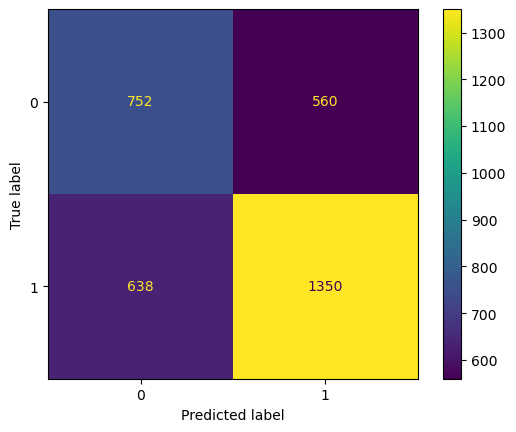

In [52]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))

In [ ]:
# false positive =560
# false negative =638


In [54]:
roc_curve(y_test,y_pred)

(array([0.        , 0.42682927, 1.        ]),
 array([0.        , 0.67907445, 1.        ]),
 array([inf,  1.,  0.]))

In [56]:
fpr,tpr,threshold=roc_curve(y_test,y_pred)

In [58]:
auc1=auc(fpr,tpr)
auc1

0.6261225891936988

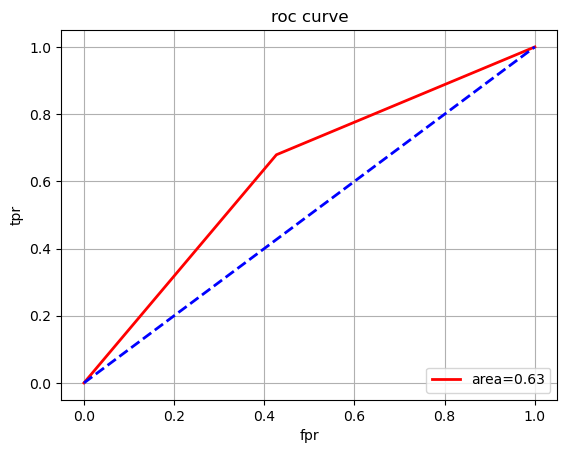

In [72]:
plt.plot(fpr,tpr,color='red',lw=2,label=f'area={auc1:.2f}')
plt.plot([0,1],[0,1],color='blue',lw=2,linestyle='--')
plt.legend(loc='lower right')
plt.title("roc curve")
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.grid()
plt.show()